/home/purco/Documents/research/hf_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66,956,548


Step,Training Loss,Validation Loss,Accuracy
100,1.381800,1.364402,0.394917
200,1.303400,1.161302,0.820167
300,0.896300,0.609352,0.871500
400,0.487200,0.410575,0.883417
500,0.391500,0.382334,0.887250
600,0.377400,0.361760,0.888667
700,0.362500,0.357524,0.889667
800,0.362500,0.353078,0.889583
900,0.358900,0.354289,0.888167
1000,0.349200,0.352897,0.888083


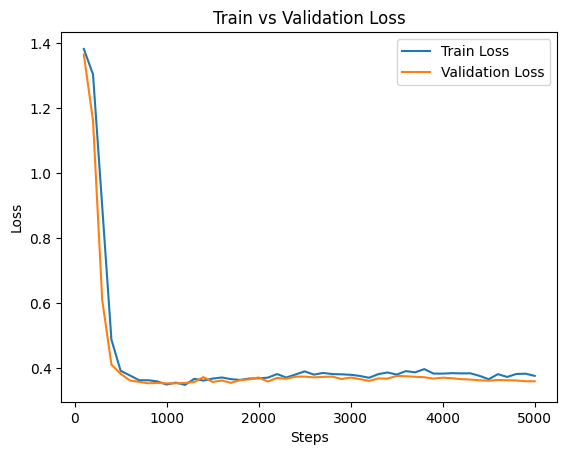

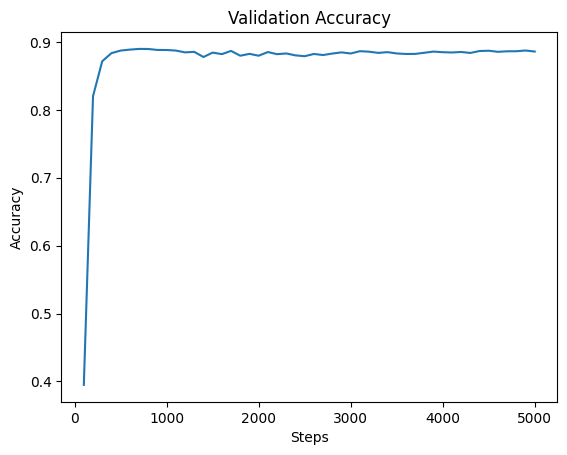

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
import torch
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
from torch.optim import Adam

RANDOM_SEED = 2026

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# load dataset
dataset = load_dataset("ag_news")

train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Create validation split
train_dataset = train_dataset.shuffle(seed=RANDOM_SEED)
split = train_dataset.train_test_split(test_size=0.1, seed=RANDOM_SEED)

train_dataset = split["train"]
val_dataset = split["test"]

# Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_fn(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_fn, batched=True)
val_dataset = val_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

# Set format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# load pretrained model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# Training arguments (adapted for logging on older transformers)
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=128,
    num_train_epochs=6,
    weight_decay=0.05,
    logging_dir="./logs",
    logging_steps=100,
    evaluation_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    report_to="none"
)

# Trainer

# Optimizer
optimizer = Adam(model.parameters(),lr=2e-5,weight_decay=0.05)
train_steps = len(train_dataset) // training_args.per_device_train_batch_size * training_args.num_train_epochs
warmup_steps = int(0.1 * train_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=train_steps
)
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, scheduler)  
)


# Train
trainer.train()

# Extract logs
log_history = trainer.state.log_history

train_steps = []
train_loss = []

eval_steps = []
val_loss = []
val_acc = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_steps.append(log["step"])
        val_loss.append(log["eval_loss"])

    if "eval_accuracy" in log:
        val_acc.append(log["eval_accuracy"])

# Plot: Train vs Validation Loss
plt.figure()
plt.plot(train_steps, train_loss, label="Train Loss")
plt.plot(eval_steps, val_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Plot: Validation Accuracy
plt.figure()
plt.plot(eval_steps, val_acc)
plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.show()

In [2]:
# Final evaluations
val_results = trainer.evaluate(val_dataset)
print(val_results)

test_results = trainer.evaluate(test_dataset)
print(test_results)

# Predictions
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=1)

# Find misclassified
mis_idx = np.where(preds != labels)[0]
mis_idx = mis_idx.astype(int)

for i in mis_idx[:10]:
    print("\n---")
    print("Decoded:", tokenizer.decode(test_dataset[i]["input_ids"], skip_special_tokens=True))
    print("True:", labels[i])
    print("Pred:", preds[i])

{'eval_loss': 0.3591803014278412, 'eval_accuracy': 0.8866666666666667, 'eval_runtime': 18.3046, 'eval_samples_per_second': 655.574, 'eval_steps_per_second': 81.947, 'epoch': 6.0}
{'eval_loss': 0.3509393036365509, 'eval_accuracy': 0.8892105263157895, 'eval_runtime': 11.9616, 'eval_samples_per_second': 635.368, 'eval_steps_per_second': 79.421, 'epoch': 6.0}


NameError: name 'mis_idx' is not defined

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup, TrainingArguments, Trainer
import torch
from torch.optim import Adam
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import random
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from torch.utils.data import DataLoader


# Seed
RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


# Load Dataset
dataset = load_dataset("ag_news")
train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Create validation split
train_dataset = train_dataset.shuffle(seed=RANDOM_SEED)
split = train_dataset.train_test_split(test_size=0.1, seed=RANDOM_SEED)
train_dataset = split["train"]
val_dataset = split["test"]


# Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_fn(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
val_dataset = val_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
    output_all_columns=True
)
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
    output_all_columns=True
)
# Load pretrained model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")


# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}


# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=128,
    num_train_epochs=6,
    weight_decay=0.05,
    logging_dir="./logs",
    logging_steps=100,
    evaluation_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    report_to="none"
)

# Optimizer and scheduler
optimizer = Adam(model.parameters(), lr=2e-5, weight_decay=0.05)
train_steps = len(train_dataset) // training_args.per_device_train_batch_size * training_args.num_train_epochs
warmup_steps = int(0.1 * train_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=train_steps
)

# Training Dynamics Tracking
train_history = defaultdict(list)

class TrackingTrainer(Trainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        output = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)
        if eval_dataset is not None and metric_key_prefix == "eval":
            self.model.eval()
            with torch.no_grad():
                for idx, batch in enumerate(eval_dataset):
                    inputs = {k: v.unsqueeze(0).to(self.model.device) for k, v in batch.items() if k != "label"}
                    label = batch["label"].unsqueeze(0).to(self.model.device)
                    logits = self.model(**inputs).logits
                    pred = logits.argmax(dim=-1)
                    train_history[idx].append(int(pred.item() == label.item()))
        return output


# Trainer
trainer = TrackingTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, scheduler)
)


# Train
trainer.train()
log_history = trainer.state.log_history


# Plot Train vs Validation Loss / Accuracy
train_steps_list, train_loss = [], []
eval_steps_list, val_loss, val_acc = [], [], []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps_list.append(log["step"])
        train_loss.append(log["loss"])
    if "eval_loss" in log:
        eval_steps_list.append(log["step"])
        val_loss.append(log["eval_loss"])
    if "eval_accuracy" in log:
        val_acc.append(log["eval_accuracy"])

plt.figure()
plt.plot(train_steps_list, train_loss, label="Train Loss")
plt.plot(eval_steps_list, val_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(eval_steps_list, val_acc)
plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.show()


# Training Dynamics Table with First Change Epoch
train_dynamics = []
for idx, history in train_history.items():
    if all(v == 0 for v in history):
        behavior = "never_correct"
        epoch_first_change = None
    elif history[0] == 1 and any(h == 0 for h in history[1:]):
        behavior = "correct_then_wrong"
        epoch_first_change = next((i+1 for i, h in enumerate(history) if h == 0), None)
    elif history[0] == 0 and any(h == 1 for h in history[1:]):
        behavior = "wrong_then_correct"
        epoch_first_change = next((i+1 for i, h in enumerate(history) if h == 1), None)
    elif all(v == 1 for v in history):
        behavior = "always_correct"
        epoch_first_change = 1
    else:
        behavior = "mixed"
        initial = history[0]
        epoch_first_change = next((i+1 for i, h in enumerate(history) if h != initial), None)
    train_dynamics.append({
        "example_idx": idx,
        "text": train_dataset[idx]["text"],
        "label": train_dataset[idx]["label"],
        "behavior": behavior,
        "first_change_epoch": epoch_first_change
    })

train_dynamics_df = pd.DataFrame(train_dynamics)
train_dynamics_df.to_csv("train_dynamics_first_change_2.csv", index=False)
print("Training dynamics saved to train_dynamics_first_change.csv")


# Function: batched CLS embeddings
def get_cls_embeddings_batched(dataset, batch_size=64):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    all_embeddings = []
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            inputs = {k: v.to(device) for k, v in batch.items() if k in ["input_ids","attention_mask"]}
            emb = model.distilbert(**inputs).last_hidden_state[:,0,:]
            all_embeddings.append(emb.cpu())
    return torch.cat(all_embeddings, dim=0).numpy()

train_embeddings = get_cls_embeddings_batched(train_dataset)
test_embeddings = get_cls_embeddings_batched(test_dataset)

/home/purco/Documents/research/hf_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66,956,548


Step,Training Loss,Validation Loss,Accuracy
100,1.381800,1.364402,0.394917
200,1.303400,1.161302,0.820167
300,0.896300,0.609352,0.871500
400,0.487200,0.410575,0.883417
500,0.391500,0.382334,0.887250
600,0.377400,0.361760,0.888667
700,0.362500,0.357524,0.889667
800,0.362500,0.353078,0.889583
900,0.358900,0.354289,0.888167
1000,0.349200,0.352897,0.888083


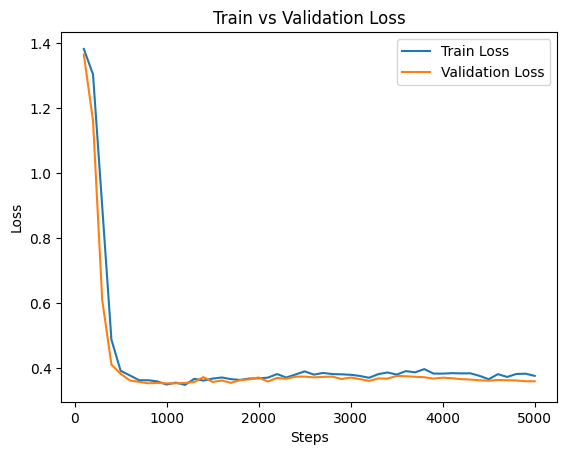

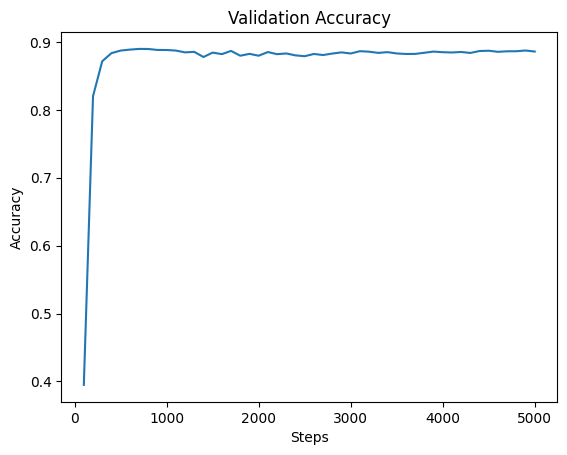

Training dynamics saved to train_dynamics_first_change.csv
Extracting train embeddings...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108000/108000 [04:57<00:00, 363.11it/s]


Extracting test embeddings...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7600/7600 [00:21<00:00, 358.87it/s]


Total misclassified: 842


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 842/842 [02:11<00:00,  6.41it/s]

Saved to test_misclassified_similarity_2.csv


In [3]:

from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import csv  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


def clean_text(s):
    return s.replace("\n", " ").replace("\r", " ")

# Extract embeddings
def get_embeddings(dataset):
    embeddings = []
    texts = []
    labels = []

    for i in tqdm(range(len(dataset))):
        item = dataset[i]

        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model.distilbert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            cls_emb = outputs.last_hidden_state[:, 0, :]

        embeddings.append(cls_emb.cpu().numpy().flatten())

        texts.append(clean_text(item["text"]))
        labels.append(int(item["label"]))

    return np.array(embeddings), texts, labels

print("Extracting train embeddings...")
train_embeddings, train_texts, train_labels = get_embeddings(train_dataset)

print("Extracting test embeddings...")
test_embeddings, test_texts, test_labels = get_embeddings(test_dataset)

# Build dataframe
train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})


# Get model predictions
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=1)

# Find misclassified examples
misclassified_idx = np.where(preds != labels)[0]

print(f"Total misclassified: {len(misclassified_idx)}")


# Similarity analysis
similarity_results = []

for idx in tqdm(misclassified_idx):
    test_emb = test_embeddings[idx].reshape(1, -1)

    sims = cosine_similarity(test_emb, train_embeddings)[0]
    top4_idx = sims.argsort()[-4:][::-1]

    similarity_results.append({
        "test_sentence": test_texts[idx],
        "true_label": int(labels[idx]),
        "predicted_label": int(preds[idx]),
        "closest_labels": [int(train_df.iloc[i]["label"]) for i in top4_idx],
        "similarities": [float(sims[i]) for i in top4_idx],
        "closest_sentences": [train_df.iloc[i]["text"] for i in top4_idx]
    })


# Convert to DataFrame
rows = []

for res in similarity_results:
    row = {
        "test_sentence": res["test_sentence"],
        "true_label": res["true_label"],
        "predicted_label": res["predicted_label"]
    }

    for i in range(4):
        row[f"closest_label_{i+1}"] = res["closest_labels"][i]
        row[f"similarity_{i+1}"] = res["similarities"][i]
        row[f"closest_sentence_{i+1}"] = res["closest_sentences"][i]

    rows.append(row)

similarity_df = pd.DataFrame(rows)
similarity_df.to_csv(
    "test_misclassified_similarity.csv",
    index=False,
    quoting=csv.QUOTE_ALL   # overcome comma issues for csv format
)

print("Saved to test_misclassified_similarity_2.csv")